In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from scipy.stats import zscore
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer
import numpy as np

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import pearsonr
import os

def metrics(method, y_test, y_pred):
    """
    Outputs classification metrics
    """
    #config_path = os.path.join(os.path.dirname(__file__), "../config.yaml")
    #with open(config_path) as f:
    #    config = yaml.safe_load(f)
    
    corr, p_value = pearsonr(y_test, y_pred)
    print(f'{method}. Classification metrics:\n')
    print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
    print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
    print(f"R²: {r2_score(y_test, y_pred)}")
    print(f"Pearson correlation coefficient: {corr}, p-value: {p_value}\n")
    
    return r2_score(y_test, y_pred)
    

# Preprocessing

In [5]:
def split_data(descriptors_path, features_file, method='RandomForestRegressor', test_size=0.1, random_state=18):

    data = pd.read_csv(descriptors_path)
    data = data.dropna()
    
    features = pd.read_csv(features_file)
    RF_features = features['RF']
    DT_features = features['DT']
    GB_features = features['GB']

    feature_sets = {"RandomForestRegressor": RF_features, 
                    "DecisionTreeRegressor": DT_features,
                   "GradientBoostingRegressor": GB_features}
    
    # Selection of specified features and target variable
    features = feature_sets[method]
    X = data[features]  # Selected features

    # Normalization
    categorial_col = [col for col in X.columns if X[col].nunique() == 2 and int(X[col].max())==1]
    numeric_col = [col for col in X.columns if not(X[col].nunique() == 2 and int(X[col].max())==1)]
    
    preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_col),
        ('cat', 'passthrough', categorial_col) 
    ])

    X_scaled = preprocessor.fit_transform(X)

    X_scaled = pd.DataFrame(X_scaled, columns=numeric_col + categorial_col)
    y = data["pIC50"]  # Target value
    y = y.str.replace(',', '.').astype(float)
    
    # Splitting
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=random_state)
    
    return X_train, X_test, y_train, y_test

In [6]:
X_train, X_test, y_train, y_test = split_data('NS3_4A_descriptors.csv', 'my_features_NS3_4A.csv', method='DecisionTreeRegressor')

In [7]:
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta
    squared_loss = 0.5 * (error ** 2)
    linear_loss = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(is_small_error, squared_loss, linear_loss))

huber_scorer = make_scorer(huber_loss, greater_is_better=False, delta=1.0)

# SVR

In [18]:
from sklearn.svm import SVR

def support_vector_regression(X_train, X_test, y_train, y_test, loss):
    
    svr = SVR()

    # Parameters for selection
    param_grid = {
        'kernel': ['rbf', 'poly'],
        'C': [0.1, 1],  # Regularization parameter
        'gamma': [0.0001, 0.001],  # Core coefficient
        'epsilon': [0.01, 0.1]  # Wide of tube
    }
    
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=18) # random splitting of data into k folds
    
    # selection of model hyperparameters using cross-validation
    grid_search = GridSearchCV(
        estimator=svr,
        param_grid=param_grid,
        scoring = loss,
        #scoring='neg_mean_squared_error',  # Optimization metric
        cv=cv,  # Number of folds
        n_jobs=-1,  # Use all CPU cores
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Best parametrs
    print(f"Best parametrs: {grid_search.best_params_} \n")
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    test_metric = metrics("Support vector regression", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    train_metric = metrics("Support vector regression", y_train, grid_search.predict(X_train))
    
    return test_metric, train_metric
    


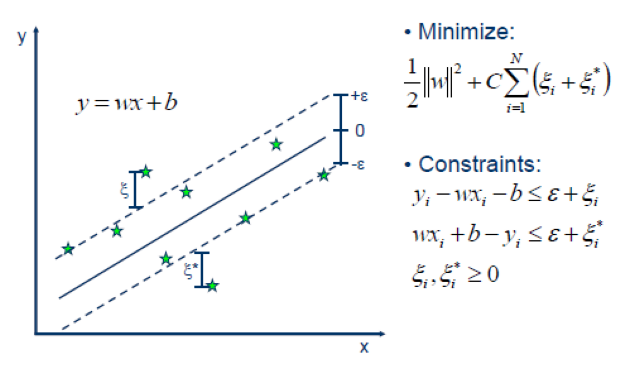

In [4]:
image = Image.open('svr.png')
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis('off')  
plt.show()
# ядро используется для вычисления сходства между объектами в расширенном пространстве признаков
# гамма: K(xi,xj)=exp(−γ∥xi−xj∥^2)

In [30]:
support_vector_regression(X_train, X_test, y_train, y_test, huber_scorer)

Best parametrs: {'C': 1, 'epsilon': 0.01, 'gamma': 0.001, 'kernel': 'rbf'} 

_______________________________________________________________
Test metrics
Support vector regression. Classification metrics:

MAE: 0.720064713954862
RMSE: 0.9626382903298967
R²: 0.6583138957168106
Pearson correlation coefficient: 0.8733409098466525, p-value: 2.742398117267721e-16

_______________________________________________________________
Train metrics
Support vector regression. Classification metrics:

MAE: 0.705328536907849
RMSE: 0.9391824196510813
R²: 0.5894531921613679
Pearson correlation coefficient: 0.7842070277609046, p-value: 2.0993882052762847e-92



In [50]:
svr_test_metric, svr_train_metric = support_vector_regression(X_train, X_test, y_train, y_test, 'neg_mean_squared_error')

Best parametrs: {'C': 1, 'epsilon': 0.01, 'gamma': 0.001, 'kernel': 'rbf'} 

_______________________________________________________________
Test metrics
Support vector regression. Classification metrics:

MAE: 0.720064713954862
RMSE: 0.9626382903298967
R²: 0.6583138957168106
Pearson correlation coefficient: 0.8733409098466525, p-value: 2.742398117267721e-16

_______________________________________________________________
Train metrics
Support vector regression. Classification metrics:

MAE: 0.705328536907849
RMSE: 0.9391824196510813
R²: 0.5894531921613679
Pearson correlation coefficient: 0.7842070277609046, p-value: 2.0993882052762847e-92



# kNN Regressor

In [23]:
from sklearn.neighbors import KNeighborsRegressor

def k_Nearest_Neighbour(X_train, X_test, y_train, y_test, loss):
    
    knn = KNeighborsRegressor()
    
    # Parameters for selection
    param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
    }
    
    # Cross-validation with GridSearchCV
    grid_search = GridSearchCV(
        estimator=knn,
        param_grid=param_grid,
        scoring=loss,
        #scoring='neg_median_absolute_error',  # Optimization metric
        cv=10,  # Number of folds
        n_jobs=-1,  # Use all CPU cores
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Best parametrs
    print("Best parametrs:", grid_search.best_params_)
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    test_metric = metrics("k Nearest Neighbour", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    train_metric = metrics("k Nearest Neighbour", y_train, grid_search.predict(X_train))
    
    return test_metric, train_metric
    

In [48]:
k_Nearest_Neighbour(X_train, X_test, y_train, y_test, huber_scorer)

Best parametrs: {'n_neighbors': 5}
_______________________________________________________________
Test metrics
k Nearest Neighbour. Classification metrics:

MAE: 0.49373145759183695
RMSE: 0.6923324737665695
R²: 0.8232617877367782
Pearson correlation coefficient: 0.9080350052830928, p-value: 2.200495273182831e-19

_______________________________________________________________
Train metrics
k Nearest Neighbour. Classification metrics:

MAE: 0.45043414917077623
RMSE: 0.623563977017775
R²: 0.8190224072661721
Pearson correlation coefficient: 0.9058269117355291, p-value: 9.975263211153747e-165



In [51]:
knn_test_metric, knn_train_metric = k_Nearest_Neighbour(X_train, X_test, y_train, y_test, 'neg_mean_squared_error')

Best parametrs: {'n_neighbors': 5}
_______________________________________________________________
Test metrics
k Nearest Neighbour. Classification metrics:

MAE: 0.49373145759183695
RMSE: 0.6923324737665695
R²: 0.8232617877367782
Pearson correlation coefficient: 0.9080350052830928, p-value: 2.200495273182831e-19

_______________________________________________________________
Train metrics
k Nearest Neighbour. Classification metrics:

MAE: 0.45043414917077623
RMSE: 0.623563977017775
R²: 0.8190224072661721
Pearson correlation coefficient: 0.9058269117355291, p-value: 9.975263211153747e-165



# MLP Regressor

In [47]:
from sklearn.neural_network import MLPRegressor

def MLP_regressor(X_train, X_test, y_train, y_test):
    
    mlp = MLPRegressor(early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=100,
    max_iter=50000,
    random_state=12)
    
    param_grid = {
    'hidden_layer_sizes': [(2,), (5,)],
    #'activation': ['logistic', 'tanh','relu'],
    #'solver': ['sgd', 'adam'],
    'learning_rate': ['adaptive'],
    'alpha': [0.5, 1],
    'learning_rate_init': [0.00001, 0.00005, 0.0001],
}
    
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=18)
     # Cross-validation with GridSearchCV
    grid_search = GridSearchCV(
        estimator=mlp,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',  # Optimization metric
        cv=cv,  # Number of folds
        n_jobs=-1,  # Use all CPU cores
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Best parametrs
    print("Best parametrs:", grid_search.best_params_)
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    test_metric = metrics("Multi-layer Perceptron regressor", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    train_metric = metrics("Multi-layer Perceptron regressor", y_train, grid_search.predict(X_train))
    
    return test_metric, train_metric
    
    

In [52]:
mlp_test_metric, mlp_train_metric = MLP_regressor(X_train, X_test, y_train, y_test)

/home/pgurzhii/miniforge3/envs/HCV/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pgurzhii/miniforge3/envs/HCV/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pgurzhii/miniforge3/envs/HCV/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pgurzhii/miniforge3/envs/HCV/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50000) reached and the optimization hasn't converged ye

Best parametrs: {'alpha': 1, 'hidden_layer_sizes': (2,), 'learning_rate': 'adaptive', 'learning_rate_init': 0.0001}
_______________________________________________________________
Test metrics
Multi-layer Perceptron regressor. Classification metrics:

MAE: 0.7220153354281719
RMSE: 0.9525730019873678
R²: 0.6654218392157609
Pearson correlation coefficient: 0.8512042300367888, p-value: 9.360385800607252e-15

_______________________________________________________________
Train metrics
Multi-layer Perceptron regressor. Classification metrics:

MAE: 0.5960573065104833
RMSE: 0.7815753252050065
R²: 0.7156819377131387
Pearson correlation coefficient: 0.8527677537467662, p-value: 4.5746803288644713e-125



In [53]:
metrics = pd.DataFrame()
metrics["DT_train"] = svr_train_metric, knn_train_metric, mlp_train_metric
metrics["DT_test"] = svr_test_metric, knn_test_metric, mlp_test_metric
metrics.index = ['SVR', 'kNN', 'MLP'] 

print(metrics)
metrics.to_csv("R2_DT.csv")

     DT_train   DT_test
SVR  0.589453  0.658314
kNN  0.819022  0.823262
MLP  0.715682  0.665422
